# PHSX 256 Topic 5: User Input, String Formatting, and File I/O (CSV & NumPy)

In [ ]:
def gravitational_potential_energy(m, h, g=9.81):
    """Compute gravitational potential energy U = m g h.

    Parameters
    ----------
    m : float
        Mass in kilograms (must be >= 0).
    h : float
        Height in meters relative to a chosen reference level.
    g : float, optional
        Gravitational acceleration in m/s^2.

    Returns
    -------
    float
        Potential energy in joules.

    Raises
    ------
    ValueError
        If m is negative.
    """
    if m < 0:
        raise ValueError("m must be non-negative")
    return m*g*h


def fall_time(h, g=9.81):
    """Return the time to fall from rest from height h (no air resistance).

    Parameters
    ----------
    h : float
        Height in meters (must be >= 0).
    g : float, optional
        Gravitational acceleration in m/s^2.

    Returns
    -------
    float
        Fall time in seconds.

    Raises
    ------
    ValueError
        If h is negative.

    Examples
    --------
    >>> fall_time(10)
    1.4...
    """
    if h < 0:
        raise ValueError("h must be non-negative")
    return math.sqrt(2*h/g)

m = 0.145
h = 20.0
U = gravitational_potential_energy(m, h)
v = drop_speed_from_height(h)
K = kinetic_energy(m, v)

print(f"U = {U:.3f} J")
print(f"v = {v:.3f} m/s")
print(f"K = {K:.3f} J")
print(f"Difference |U-K| = {abs(U-K):.6f} J")
print(f"Fall time (exact): {fall_time(h):.3f} s")

## Setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## User input

`input(prompt)` **returns a string**. For physics computations, convert to numbers with `float()` or `int()`. Use `try/except` to catch invalid input and provide fallbacks.

**Common patterns**
- Include **units** in the prompt.
- Validate the **physical domain** (e.g., mass $m\ge 0$).
- Provide **defaults** when parsing fails.

**Example:** kinetic energy $K = \tfrac{1}{2}\,m\,v^2$.

In [2]:
# Safer input with validation
try:
    m = float(input('Enter mass m in kg (>= 0): '))
    if m < 0:
        raise ValueError('Mass must be non-negative')
    v = float(input('Enter speed v in m/s: '))
except Exception as e:
    print('Using defaults due to input issue:', e)
    m, v = 0.145, 40.0

K = 0.5 * m * v**2
print(f"K = {K:.3f} J")

Enter mass m in kg (>= 0):  5
Enter speed v in m/s:  8


K = 160.000 J


### Sample problems — user input
1. Ask the user for height $h$ (m) and compute free‑fall time from rest using $t = \sqrt{\tfrac{2h}{g}}$ with $g=9.81\,\text{m/s}^2$. Validate $h \ge 0$.
2. Ask for temperature in $^\circ\!\text{C}$ and print it in K using $T_{\mathrm{K}} = T_{^\circ\!\mathrm{C}} + 273.15$.
3. Ask for launch speed $v$ and angle $\theta$ (deg). Compute ideal range $R = \dfrac{v^2\sin(2\theta)}{g}$ (convert degrees to radians). Print $R$ with fixed and scientific formatting.

## String formatting — f‑strings

**f‑strings** evaluate expressions inside `{}` and support **format specifiers** after a colon.

**Essentials**
- Fixed decimals: `{x:.3f}`
- Scientific notation: `{x:.2e}`
- Width & alignment: `{x:10.3f}`, `{label:>8}`, `{label:<8}`
- Thousands separator: `{n:,}`

We’ll reuse $K$ and show angle conversion where $\theta_{\mathrm{rad}} = \theta_{\mathrm{deg}}\,\tfrac{\pi}{180}$.

In [3]:
# Demonstrations
print(f"K (no formatting): {K} J")
print(f"K (3 decimals): {K:.3f} J")
print(f"K (scientific): {K:.3e} J")

theta_deg = 35.0
theta_rad = np.deg2rad(theta_deg)
print(f"theta = {theta_deg:.1f} deg = {theta_rad:.3f} rad")

# Aligned table for K = 1/2 m v^2
rows = [(0.145, 40.0), (0.50, 12.5), (1.0, 3.0)]
print(f"{'m (kg)':>8} {'v (m/s)':>10} {'K (J)':>12}")
for m0, v0 in rows:
    K0 = 0.5*m0*v0**2
    print(f"{m0:8.3f} {v0:10.2f} {K0:12.3f}")

K (no formatting): 160.0 J
K (3 decimals): 160.000 J
K (scientific): 1.600e+02 J
theta = 35.0 deg = 0.611 rad
  m (kg)    v (m/s)        K (J)
   0.145      40.00      116.000
   0.500      12.50       39.062
   1.000       3.00        4.500


### Sample problems — f‑strings
1. Print a table of heights $h$ (m) and exact fall times $t=\sqrt{\tfrac{2h}{g}}$ with columns aligned and times to 3 decimals.
2. For speeds $v$, print $\gamma = \dfrac{1}{\sqrt{1-(v/c)^2}}$ (with $c=3.00\times10^8\,\text{m/s}$) using scientific notation with 2 decimals.
3. Format a sentence: _"At $t=\,1.50\,\text{s}$ the velocity is $-14.7\,\text{m/s}$"_ using variables.

## f-strings: exhaustive format specifiers (mini reference)

General form inside an f-string: ``{value!conversion:format_spec}``

- **Conversions (optional)**: `!s` (string), `!r` (repr), `!a` (ascii). Example: ``f"{x!r}"``.
- **Format spec (after `:`)** follows the format specification mini-language.

### Numeric types (int/float/complex)
``{value:[fill][align][sign][#][0][width][,][.precision][type]}``

- **fill**: any character for padding (e.g., `_`, space).
- **align**: `<` left, `>` right, `^` center, `=` pad after sign (numbers).
- **sign**: `+` always, `-` only negatives, space for positives.
- **`#`**: alternate form—base prefixes (`0b`,`0o`,`0x`) or decimal point for floats.
- **`0`**: zero-pad to `width` (equivalent to `fill='0'` and `align='='`).
- **width**: minimum field width.
- **`,`**: thousands separator; `n` type is locale-aware.
- **precision**: floats → digits after decimal; `g` → significant digits.
- **type**:
  - Integers: `b` `c` `d` `o` `x` `X` `n`
  - Floats: `e` `E` `f` `F` `g` `G` `%` `n` (or none → `g`)

**Examples**
```python
E = 12345.6789
print(f"{E:>12.2f}")   # '     12345.68'
print(f"{E:012.2f}")   # '0000012345.68'
print(f"{E:,.2f}")     # '12,345.68'
print(f"{E:.3e}")      # '1.235e+04'
print(f"{E:#.0f}")     # '12346.' (forces decimal point)
print(f"{255:#x}")     # '0xff'
```

### Strings
``{value:[fill][align][width][.precision]}`` — precision **truncates**.
```python
s = 'physics'
print(f"{s:>10}")   # right-align width 10
print(f"{s:.3}")    # 'phy'
print(f"{s:*^12}")  # center with fill '*'
```

> Tip: Prefer **f-strings** for readability; the same specifiers also work with `format()`.

## File I/O — CSV and NumPy formats

- **CSV**: human‑readable text; good for spreadsheets and reports.
- **NumPy** `.npy` / `.npz`: binary, preserves dtype/shape, faster for large arrays.

We will generate free‑fall data using $y(t)=y_0-\tfrac{1}{2}g t^2$ and $v(t)=-g t$, save to CSV, read it back (two methods), and then save/load as NumPy binary files.

## The `with` statement for files (context managers)

The **`with` statement** (a *context manager*) is the safest and most Pythonic way to open files. It **automatically closes** the file when the block ends—**even if an exception occurs**—so you don't leak OS file handles.

**Pattern:**
```python
with open('path/to/file.txt', mode='w', encoding='utf-8') as f:
    f.write('Hello, file!\n')
# file is closed here
```

**Why it matters for physics code:**
- Prevents files from staying open and locking directories during labs.
- Ensures data is flushed/closed properly so your results are actually on disk.
- Makes exception paths safer (no forgotten `f.close()`).

> For CSVs on Windows, use `newline=''` in `open(...)` to avoid blank lines.

### `with` + text files (write, then read)
We write a tiny notes file and then read it back. This mirrors lab notes or short metadata blocks.

In [5]:
# Write with context manager
with open("lab_notes.txt", 'w', encoding='utf-8') as f:
    f.write('Experiment: Free-fall test')
    f.write('g = 9.81 m/s^2')

# Read with context manager
with open("lab_notes.txt", 'r', encoding='utf-8') as f:
    for line in f:
        print(line)

Experiment: Free-fall testg = 9.81 m/s^2


### `with` + CSV
Our CSV code already uses `with` when opening files:
```python
with open(filename, 'w', newline='') as f:
    w = csv.writer(f)
    ...
```
This is the recommended pattern for all CSV reads/writes.

### CSV: write data
- Include a header with names and units.
- Use `csv.writer` for general data.
- Use `numpy.savetxt` for numerical array data.

In [22]:
import csv

# Generate free-fall data and write CSV
g = 9.81
y0 = 20.0

t = np.arange(0.0, 2.2, 0.1)
y = y0 - 0.5*g*t**2
v = -g*t

with open('free_fall.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['t_s','y_m','v_m_per_s'])
    for ti, yi, vi in zip(t, y, v):
        w.writerow([f'{ti:.3f}', f'{yi:.5f}', f'{vi:.5f}'])

print('Wrote csv')

# Using numpy
#np.savetxt('free_fall.csv', np.column_stack([t, y, v]), fmt='%.6e', delimiter=',', newline='\n', header='t_s, y_m, v_m_per_s', comments='# ')

Wrote csv


### CSV: read data
- `csv.DictReader` for flexible parsing.
- `numpy.loadtxt` for numerical array data.

Loaded shapes (csv): (22,) (22,) (22,)


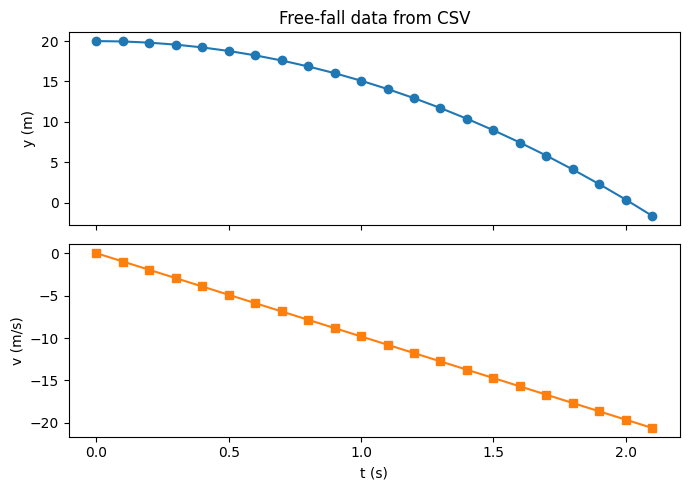

In [18]:
# Read CSV using csv.DictReader
T, Y, V = [], [], []
with open('free_fall.csv', 'r', newline='') as f:
    r = csv.DictReader(f)
    for row in r:
        T.append(float(row['t_s']))
        Y.append(float(row['y_m']))
        V.append(float(row['v_m_per_s']))

T = np.array(T); Y = np.array(Y); V = np.array(V)
print('Loaded shapes (csv):', T.shape, Y.shape, V.shape)

# Plot
fig, ax = plt.subplots(2,1, figsize=(7,5), sharex=True)
ax[0].plot(T, Y, 'o-'); ax[0].set_ylabel('y (m)')
ax[1].plot(T, V, 's-', color='tab:orange'); ax[1].set_ylabel('v (m/s)'); ax[1].set_xlabel('t (s)')
ax[0].set_title('Free-fall data from CSV')
plt.tight_layout(); plt.show()

In [8]:
# Read CSV using NumPy
arr = np.loadtxt('free_fall.csv', delimiter=',', skiprows=1)
T_np, Y_np, V_np = arr.T
acc_est = np.gradient(V_np, T_np)
print(f'Mean acceleration ~ {acc_est.mean():.3f} m/s^2 (should be about -{g})')

# Write a summary CSV with acceleration
with open('free_fall_summary.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['t_s','v_m_per_s','a_m_per_s2'])
    for ti, vi, ai in zip(T_np, V_np, acc_est):
        w.writerow([f'{ti:.3f}', f'{vi:.5f}', f'{ai:.5f}'])
print('Wrote summary')

Mean acceleration ~ -9.810 m/s^2 (should be about -9.81)
Wrote summary


### NumPy binary: save and load arrays
- Save one array: `np.save('file.npy', A)` / load with `np.load('file.npy')`.
- Save multiple arrays together: `np.savez('file.npz', A=A, B=B, ...)`.

In [10]:
# Save separate arrays as .npy
np.save('T.npy', T_np)
np.save('Y.npy', Y_np)
np.save('V.npy', V_np)

# Save multiple arrays together as .npz
np.savez('free_fall.npz', T=T_np, Y=Y_np, V=V_np)
print('Saved .npy and .npz files')

# Load them back
T_loaded = np.load('T.npy')
Y_loaded = np.load('Y.npy')
V_loaded = np.load('V.npy')
npz = np.load('free_fall.npz')
print('From .npy:', T_loaded.shape, Y_loaded.shape, V_loaded.shape)
print('From .npz keys:', list(npz.keys()))

Saved .npy and .npz files
From .npy: (22,) (22,) (22,)
From .npz keys: ['T', 'Y', 'V']


## Strategies for very large data files (performance & reliability)

When arrays or tables are **too large** for memory or I/O becomes the bottleneck, use these:

### Efficient formats & dtypes
- Prefer **NumPy binary** (`.npy` / `.npz`) over CSV for speed and exact shapes.
- Downcast to smaller dtypes if acceptable (e.g., `float32`, `int16`).
```python
arr64 = np.random.rand(1_000_000).astype(np.float64)
arr32 = arr64.astype(np.float32)
np.save('data_f32.npy', arr32)
```

### Chunked processing
Read/write and process in **chunks** to keep memory bounded.

### Compression
Use `np.savez_compressed` for space savings (CPU trade‑off) and external compression for CSV (e.g., `.gz`).

### Sample problems — file I/O and `with`
1. **CSV**: From the loaded $t$, $y$, $v$, compute discrete acceleration $a$ and append it as a new CSV column. Verify mean $a \approx -g$.
2. **`.npz`**: Create datasets for two different $y_0$ values and save as `free_fall_two_cases.npz` with keys `T1, Y1, V1, T2, Y2, V2`. Load and **plot** both $y(t)$ curves on the same axes.
3. **Round‑trip**: Generate a random array, save as `.npy`, load it back, and assert equality with `np.allclose`.
4. **`with`**: Create `results_log.txt` and append a one‑line summary each time you compute a new $K = \tfrac{1}{2} m v^2$ (mode `'a'`).